# Biblioteka Matplotlib - Część 2

## Wykresy liniowe oraz słupkowe

W tej części nauczysz się tworzyć dwa podstawowe typy wykresów: liniowe (`plot`) do pokazywania trendów i zmian w czasie oraz słupkowe (`bar`, `barh`) do porównywania kategorii. Poznasz też wykresy grupowane i skumulowane.

### Import biblioteki

Matplotlib importujemy zazwyczaj jako `plt` (przyjęta konwencja):

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ustawienie, żeby wykresy pokazywały się w notebooku
%matplotlib inline

print("Matplotlib zaimportowany pomyślnie!")
print(f"Wersja: {plt.matplotlib.__version__}")

Matplotlib zaimportowany pomyślnie!
Wersja: 3.11.0


## 1. Wykres liniowy (`plot`)

Wykres liniowy służy do pokazywania trendów i zmian w czasie.

**Kiedy używać:**
- Dane czasowe (np. temperatura w ciągu roku)
- Ciągłe zmiany wartości
- Porównanie wielu serii danych

**Składnia podstawowa:**
```python
ax.plot(x, y)
```

### Przykład 1: Prosty wykres liniowy - temperatura w czasie

In [7]:
# Wczytanie danych pogodowych
df_pogoda = pd.read_csv('../data/pogoda.csv')


In [8]:
# Wczytanie danych pogodowych
df_pogoda = pd.read_csv('../data/pogoda.csv')

# Konwersja kolumny data na typ datetime
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])

# Wyświetl pierwsze wiersze
print(df_pogoda.head())
print(f"\nLiczba rekordów: {len(df_pogoda)}")

        data  temperatura  opady  wilgotnosc
0 2023-01-01         -2.5    0.0          75
1 2023-01-02         -3.8    0.5          78
2 2023-01-03         -1.2    0.0          72
3 2023-01-04          0.5    1.2          80
4 2023-01-05          1.2    2.5          82

Liczba rekordów: 170


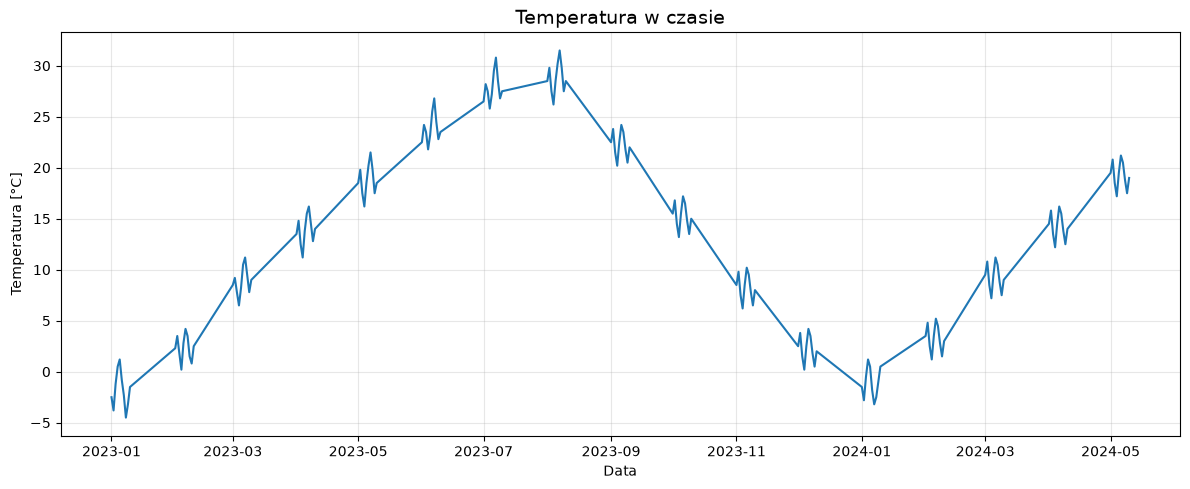

In [9]:
# Wykres temperatury w czasie
fig, ax = plt.subplots(figsize=(12, 5))  # 12 cali szerokości x 5 cali wysokości

ax.plot(df_pogoda['data'], df_pogoda['temperatura'])

ax.set_title('Temperatura w czasie', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Temperatura [°C]')
ax.grid(True, alpha=0.3)  # alpha kontroluje przezroczystość

plt.tight_layout()  # Automatyczne dopasowanie
plt.show()

**💡 Co oznacza `figsize=(12, 5)`?**

`figsize=(12, 5)` określa rozmiar figury (całego wykresu):
- **12 cali szerokości** × **5 cali wysokości**
- Przy domyślnym `dpi=100` (100 pikseli na cal) → obraz będzie miał **1200×500 pikseli**
- **Wzór:** rozmiar w pikselach = `figsize × dpi`

**Przykłady:**
- `figsize=(12, 5), dpi=100` → 1200×500 px (standard)
- `figsize=(10, 6), dpi=150` → 1500×900 px (większy, ostrzejszy)
- `figsize=(8, 4), dpi=72` → 576×288 px (mały)

**📚 Szczegóły:** Zobacz `matplotlib_faq.ipynb` → pytanie 3: "Co oznacza figsize i DPI?"

**💡 Co robi `plt.tight_layout()`?**

`tight_layout()` automatycznie **dopasowuje marginesy** wokół wykresu, żeby wszystkie elementy (tytuły, etykiety osi, legendy) się mieściły bez przycinania.

**Jak działa:**
- Matplotlib oblicza ile miejsca zajmują wszystkie teksty (tytuł, etykiety osi, ticklabels)
- Automatycznie powiększa marginesy, żeby nic nie było przycięte
- Szczególnie przydatne gdy etykiety osi X są obrócone (`plt.xticks(rotation=45)`)

**Bez `tight_layout()`:** Długie etykiety mogą być przycięte na brzegach  
**Z `tight_layout()`:** Wszystko ładnie się mieści

---

### Przykład 2: Wiele linii na jednym wykresie

Możemy łatwo porównać kilka serii danych:

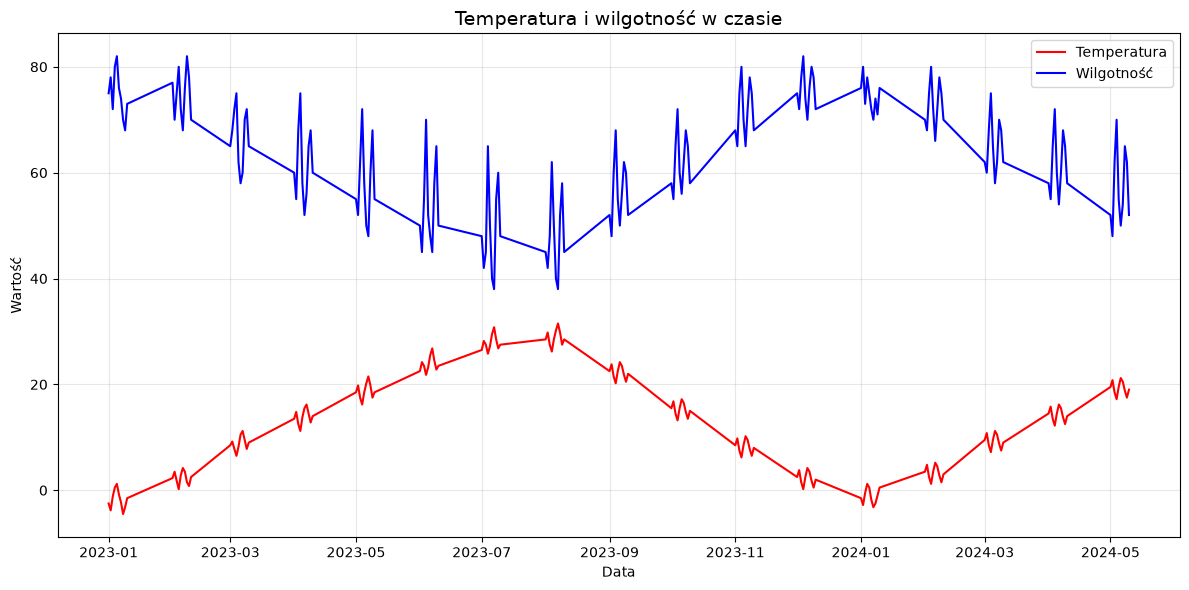

In [10]:
# Wiele linii na jednym wykresie
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_pogoda['data'], df_pogoda['temperatura'], label='Temperatura', color='red')
ax.plot(df_pogoda['data'], df_pogoda['wilgotnosc'], label='Wilgotność', color='blue')

ax.set_title('Temperatura i wilgotność w czasie', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Wartość')
ax.legend()  # Dodaj legendę
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Uwaga:** Ten wykres ma problem - temperatura i wilgotność mają różne skale!

Temperatura: -5°C do 32°C

Wilgotność: 38% do 82%

Lepiej użyć dwóch osobnych osi Y (poznasz to później w zaawansowanych technikach).

### Podstawowe parametry funkcji `plot()`

```python
ax.plot(x, y, 
        color='blue',      # Kolor linii
        linewidth=2,       # Grubość linii
        linestyle='-',     # Styl linii: '-', '--', '-.', ':'
        marker='o',        # Znacznik punktów: 'o', 's', '^', '*'
        markersize=5,      # Rozmiar znacznika
        label='Nazwa')     # Etykieta dla legendy
```

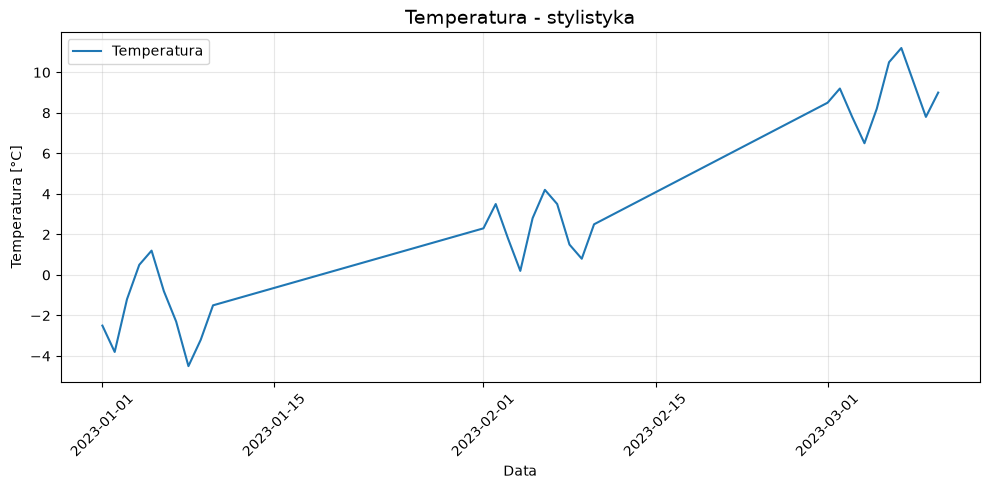

In [12]:
# Przykład z różnymi stylami
fig, ax = plt.subplots(figsize=(10, 5))

# Wybierz tylko pierwsze 30 dni dla czytelności
dane_skrocone = df_pogoda.head(30)

ax.plot(dane_skrocone['data'], dane_skrocone['temperatura'], label="Temperatura")

ax.set_title('Temperatura - stylistyka', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Temperatura [°C]')
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)  # Obróć etykiety osi X
plt.tight_layout()
plt.show()

---
## Ćwiczenie 2.1 (w trakcie) - Wykres sprzedaży w czasie

**Cel:** Stworzyć wykres liniowy pokazujący trend sprzedaży.

**Zadanie:**
1. Wczytaj dane z `data/sprzedaz.csv`
2. Przekonwertuj kolumnę `data` na typ datetime
3. Oblicz całkowitą sprzedaż dla każdego dnia (kwota * ilosc)
4. Utwórz wykres liniowy pokazujący całkowitą sprzedaż w czasie
5. Dodaj tytuł, opisy osi i siatkę

**Wskazówka:** Użyj `df['nowa_kolumna'] = df['kolumna1'] * df['kolumna2']`

**Czas:** 10 minut

In [ ]:
# TWÓJ KOD TUTAJ
# 1. Wczytaj dane


# 2. Przekonwertuj datę


# 3. Oblicz całkowitą sprzedaż


# 4-5. Utwórz wykres



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# 1. Wczytaj dane
df_sprzedaz = pd.read_csv('data/sprzedaz.csv')

# 2. Przekonwertuj datę
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])

# 3. Oblicz całkowitą sprzedaż
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

# 4-5. Utwórz wykres
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_sprzedaz['data'], df_sprzedaz['wartosc_sprzedazy'], 
        color='green', linewidth=1.5, marker='o', markersize=3)

ax.set_title('Wartość sprzedaży w czasie', fontsize=14, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Maksymalna sprzedaż: {df_sprzedaz['wartosc_sprzedazy'].max():.2f} zł")
print(f"Minimalna sprzedaż: {df_sprzedaz['wartosc_sprzedazy'].min():.2f} zł")
print(f"Średnia sprzedaż: {df_sprzedaz['wartosc_sprzedazy'].mean():.2f} zł")
```

</details>

---
## Ćwiczenie 2.2 (do domu) - Porównanie sprzedaży różnych produktów

**Cel:** Porównać trendy sprzedaży dla różnych kategorii produktów.

**Zadanie:**
1. Użyj danych sprzedażowych wczytanych wcześniej
2. Pogrupuj dane według kategorii i daty, sumując wartość sprzedaży
3. Utwórz wykres z trzema liniami - po jednej dla każdej kategorii:
   - Komputery
   - Peryferia
   - Audio
4. Dodaj legendę, tytuł, opisy osi
5. Użyj różnych kolorów dla każdej kategorii

**Wskazówka:** Użyj `df.groupby(['kategoria', 'data'])['wartosc_sprzedazy'].sum()`

**Czas:** 20 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Grupowanie i agregacja
sprzedaz_kategorie = df_sprzedaz.groupby(['kategoria', 'data'])['wartosc_sprzedazy'].sum().reset_index()

# Wykres
fig, ax = plt.subplots(figsize=(14, 6))

# Dla każdej kategorii osobna linia
for kategoria in sprzedaz_kategorie['kategoria'].unique():
    dane_kat = sprzedaz_kategorie[sprzedaz_kategorie['kategoria'] == kategoria]
    ax.plot(dane_kat['data'], dane_kat['wartosc_sprzedazy'], 
            marker='o', markersize=4, linewidth=2, label=kategoria)

ax.set_title('Sprzedaż według kategorii w czasie', fontsize=14, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.legend(title='Kategoria', fontsize=10)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Wnioski
print("Średnia sprzedaż według kategorii:")
print(sprzedaz_kategorie.groupby('kategoria')['wartosc_sprzedazy'].mean())
```

</details>

---
## 3. Wykres słupkowy (`bar`, `barh`)

Wykres słupkowy służy do porównywania wartości między kategoriami.

**Kiedy używać:**
- Porównanie kategorii (np. sprzedaż produktów)
- Ranking (np. top 10)
- Dane dyskretne

**Dwa typy:**
- `ax.bar()` - słupki pionowe
- `ax.barh()` - słupki poziome (lepsze dla długich nazw kategorii)

### Przykład 1: Sprzedaż według kategorii

In [13]:
# Wczytanie danych sprzedażowych
df_sprzedaz = pd.read_csv('../data/sprzedaz.csv')

# Konwersja kolumny data na typ datetime
df_sprzedaz['data'] = pd.to_datetime(df_sprzedaz['data'])

# Oblicz wartość sprzedaży (kwota × ilość)
df_sprzedaz['wartosc_sprzedazy'] = df_sprzedaz['kwota'] * df_sprzedaz['ilosc']

# Wyświetl pierwsze wiersze
print(df_sprzedaz.head())
print(f"\nLiczba rekordów: {len(df_sprzedaz)}")

        data     produkt  kategoria   kwota  ilosc  wartosc_sprzedazy
0 2023-01-15      Laptop  Komputery  4500.0      5            22500.0
1 2023-01-18     Monitor  Peryferia   850.0     12            10200.0
2 2023-01-22  Klawiatura  Peryferia   250.0     18             4500.0
3 2023-01-25        Mysz  Peryferia   120.0     25             3000.0
4 2023-01-28   Słuchawki      Audio   380.0     15             5700.0

Liczba rekordów: 123


In [17]:
# Agregacja - suma sprzedaży według kategorii
sprzedaz_kat = df_sprzedaz.groupby('kategoria')['wartosc_sprzedazy'].sum().reset_index()

print(sprzedaz_kat)

   kategoria  wartosc_sprzedazy
0      Audio           345260.0
1  Komputery          1850500.0
2  Peryferia           603800.0


**💡 Co robi `.reset_index()`?**

Po `groupby().sum()` pandas zwraca **Series** z kategorią jako **indeksem**:
```
kategoria
Audio        345260.0
Komputery   1850500.0
Peryferia    603800.0
```

`.reset_index()` **przekształca to w DataFrame** z kategorią jako **zwykłą kolumną**:
```
   kategoria  wartosc_sprzedazy
0      Audio           345260.0
1  Komputery          1850500.0
2  Peryferia           603800.0
```

**Po co?** Żeby łatwo odwoływać się do kolumn: `df['kategoria']`, `df['wartosc_sprzedazy']`

**📚 Szczegóły:** Zobacz `00_extras/pandas/01_struktury_danych.ipynb`

---

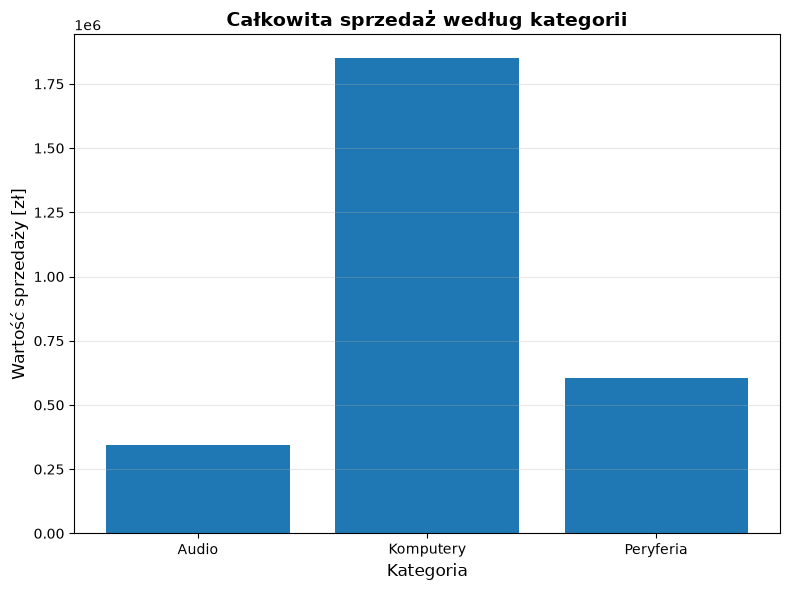

In [18]:
# Wykres słupkowy pionowy
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(sprzedaz_kat['kategoria'], sprzedaz_kat['wartosc_sprzedazy'])

ax.set_title('Całkowita sprzedaż według kategorii', fontsize=14, fontweight='bold')
ax.set_xlabel('Kategoria', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.grid(axis='y', alpha=0.3)  # Tylko pozioma siatka

plt.tight_layout()
plt.show()

### Przykład 2: Wykres słupkowy poziomy

Przydatny gdy mamy długie nazwy:

In [ ]:
# Top 10 produktów według wartości sprzedaży
top_produkty = df_sprzedaz.groupby('produkt')['wartosc_sprzedazy'].sum().nlargest(10).reset_index()

print(top_produkty)

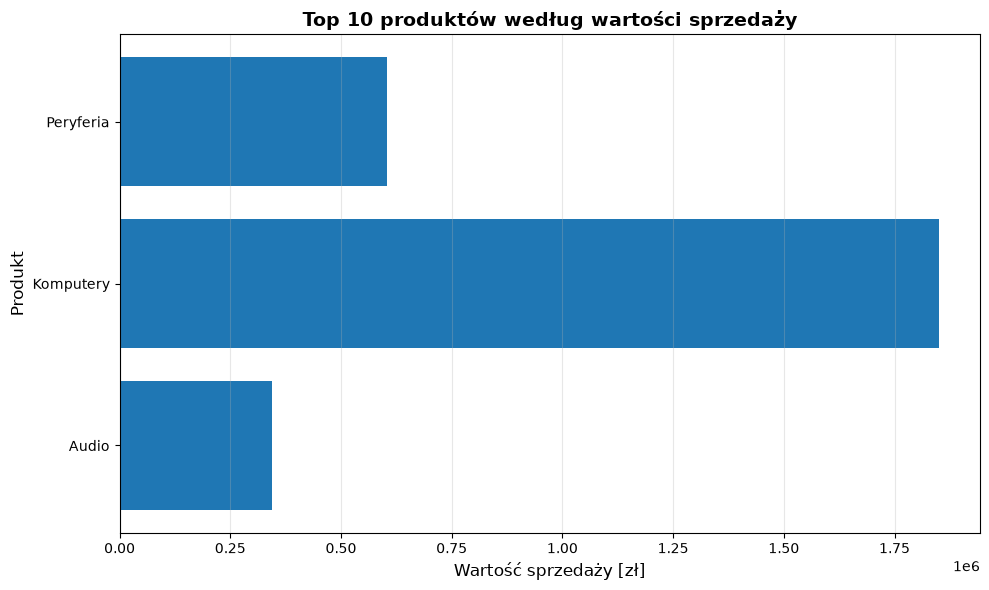

In [19]:
# Wykres słupkowy poziomy
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(sprzedaz_kat['kategoria'], sprzedaz_kat['wartosc_sprzedazy'])

ax.set_title('Top 10 produktów według wartości sprzedaży', fontsize=14, fontweight='bold')
ax.set_xlabel('Wartość sprzedaży [zł]', fontsize=12)
ax.set_ylabel('Produkt', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Przykład 3: Grouped bar chart (wykres słupkowy grupowany)

**Po co?** Porównanie **wielu metryk** dla tych samych kategorii **obok siebie**

**Kiedy używać:**
- Chcesz porównać 2-3 różne metryki dla tych samych grup
- Metryki mają **podobne skale** (lub można użyć dwóch osi Y)
- Ważne jest **bezpośrednie porównanie** w obrębie kategorii

**Przykład:** Sprzedaż vs Zysk dla każdego produktu

```
Produkt A:  [Sprzedaż: 100] [Zysk: 30]  ← obok siebie, łatwo porównać
Produkt B:  [Sprzedaż: 150] [Zysk: 20]  ← B ma wyższą sprzedaż, ale niższy zysk!
Produkt C:  [Sprzedaż: 80]  [Zysk: 40]  ← C ma najniższą sprzedaż, ale najwyższy zysk!
```

**Alternatywa:** Jeśli metryki mają bardzo różne skale (np. pensja w tys. zł vs liczba osób), lepiej użyć **dwóch osobnych wykresów** lub **stacked bar** (jeśli metryki się sumują).

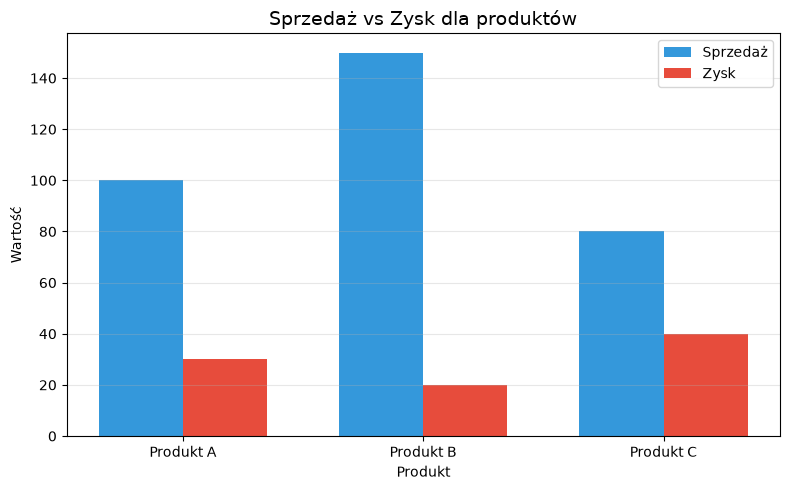

In [20]:
# Dane syntetyczne z opisu
produkty = ['Produkt A', 'Produkt B', 'Produkt C']
sprzedaz = [100, 150, 80]
zysk = [30, 20, 40]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(produkty))
width = 0.35

ax.bar(x - width/2, sprzedaz, width, label='Sprzedaż', color='#3498db')
ax.bar(x + width/2, zysk, width, label='Zysk', color='#e74c3c')

ax.set_title('Sprzedaż vs Zysk dla produktów', fontsize=14)
ax.set_xlabel('Produkt')
ax.set_ylabel('Wartość')
ax.set_xticks(x)
ax.set_xticklabels(produkty)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Wczytaj dane pracowników
df_prac = pd.read_csv('../data/pracownicy.csv')

# Średnia pensja według działu
avg_pensja = df_prac.groupby('dzial')['pensja'].mean()
# Liczba pracowników według działu
liczba_prac = df_prac.groupby('dzial').size()

print("Średnia pensja według działów:")
print(avg_pensja)
print("\nLiczba pracowników według działów:")
print(liczba_prac)

Średnia pensja według działów:
dzial
Finanse      10228.571429
HR            6800.000000
IT           11161.538462
Marketing     5837.500000
Sprzedaż      5540.000000
Name: pensja, dtype: float64

Liczba pracowników według działów:
dzial
Finanse       7
HR            4
IT           26
Marketing     8
Sprzedaż      5
dtype: int64


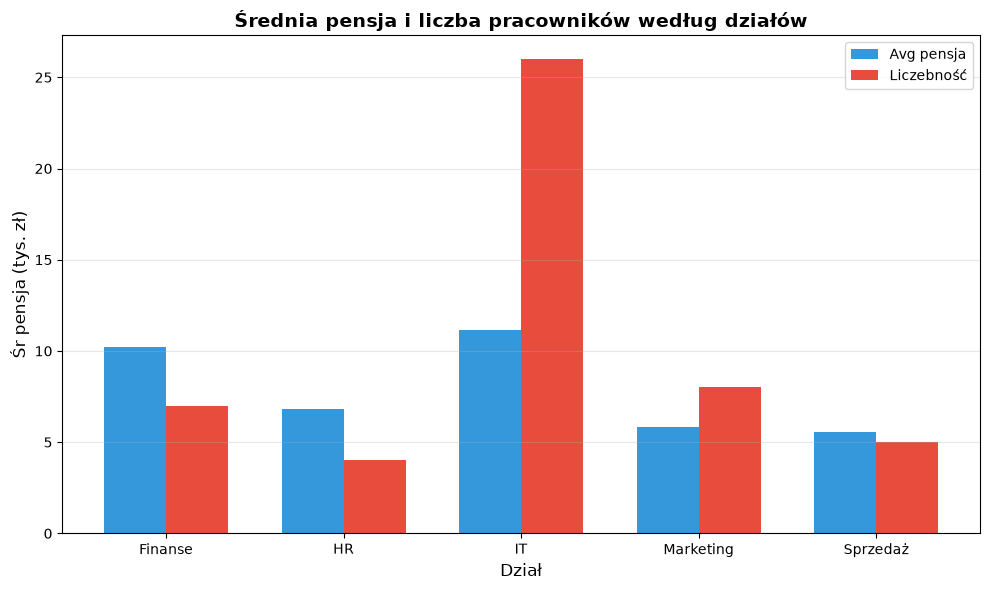

In [25]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

dzialy = avg_pensja.index
x = np.arange(len(dzialy))  # Pozycje słupków
width = 0.35  # Szerokość słupka

# Dwa zestawy słupków
ax.bar(x - width/2, avg_pensja/1000, width, label='Avg pensja', color='#3498db')
ax.bar(x + width/2, liczba_prac, width, label='Liczebność', color='#e74c3c')

ax.set_title('Średnia pensja i liczba pracowników według działów', fontsize=14, fontweight='bold')
ax.set_ylabel('Śr pensja (tys. zł)', fontsize=12)
ax.set_xlabel('Dział', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(dzialy)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Uwaga:** Ten wykres ma problem - pensje i liczba pracowników mają różne skale! Posługują się innymi jednostkami i tylko dzięki temu, że pensje przeskalowaliśmy do tys. zł, możemy coś z tego wykresu odczytać. To może wprowadzać w błąd.

Lepiej zrobić dwa osobne wykresy lub użyć dwóch osi Y.

### Przykład 4: Stacked bar chart (wykres słupkowy skumulowany)

**Po co?** Pokazanie **struktury całości** - jak poszczególne części składają się na sumę

**Kiedy używać:**
- Chcesz pokazać **udział** każdej kategorii w całości
- Metryki **się sumują** (np. sprzedaż różnych produktów = całkowita sprzedaż)
- Interesuje Cię zarówno **całość** jak i **rozkład wewnętrzny**

**Przykład:** Sprzedaż produktów A, B, C w każdym miesiącu

```
Styczeń:   [A: 50] [B: 30] [C: 20]  = Razem: 100
Luty:      [A: 60] [B: 40] [C: 30]  = Razem: 130  ← Wzrost całości!
Marzec:    [A: 40] [B: 50] [C: 40]  = Razem: 130  ← Ta sama suma, ale B rośnie, A spada
```

**Wizualnie:**
```
     │ C │  ← Produkt C (top)
     ├───┤
     │ B │  ← Produkt B (środek)
     ├───┤
     │ A │  ← Produkt A (bottom)
     └───┘
    Styczeń
```
Każdy słupek = **całkowita sprzedaż**, podzielona na **segmenty**

**Co widzisz:**
- ✅ **Wysokość całego słupka** = suma (całkowita sprzedaż)
- ✅ **Wysokość segmentu** = udział produktu
- ✅ **Trendy** - który produkt rośnie/spada w strukturze

**Uwaga:** Trudniej porównać **bezpośrednio** środkowe/górne segmenty (nie mają wspólnej linii bazowej)

**Kiedy NIE używać:** Jeśli metryki się **nie sumują** (np. temperatura i wilgotność) - użyj **grouped bar** lub **dwóch osobnych wykresów**

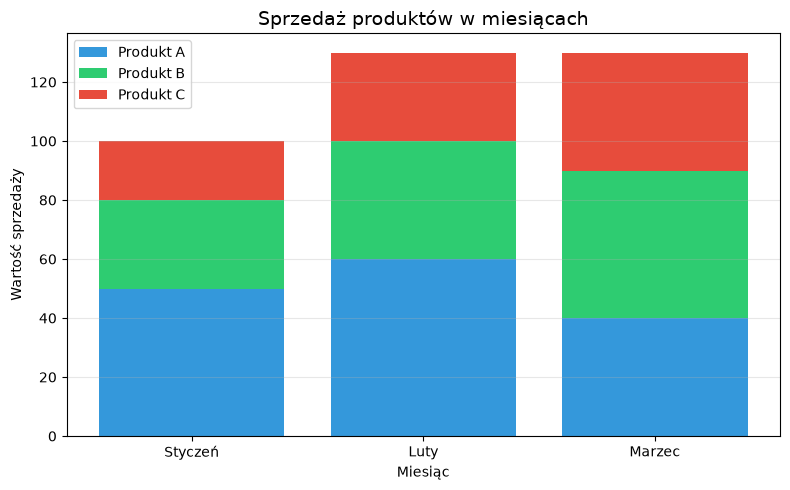

In [26]:
# Dane syntetyczne z opisu
miesiace = ['Styczeń', 'Luty', 'Marzec']
produkt_a = [50, 60, 40]
produkt_b = [30, 40, 50]
produkt_c = [20, 30, 40]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(miesiace))

ax.bar(x, produkt_a, label='Produkt A', color='#3498db')
ax.bar(x, produkt_b, bottom=produkt_a, label='Produkt B', color='#2ecc71')
ax.bar(x, produkt_c, bottom=np.array(produkt_a)+np.array(produkt_b), label='Produkt C', color='#e74c3c')

ax.set_title('Sprzedaż produktów w miesiącach', fontsize=14)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Wartość sprzedaży')
ax.set_xticks(x)
ax.set_xticklabels(miesiace)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Sprzedaż według kategorii w każdym kwartale
# Dodaj kolumnę kwartału
df_sprzedaz['kwartal'] = df_sprzedaz['data'].dt.quarter
df_sprzedaz['rok'] = df_sprzedaz['data'].dt.year

# Agregacja
kwartalnie = df_sprzedaz.groupby(['rok', 'kwartal', 'kategoria'])['wartosc_sprzedazy'].sum().unstack()

print(kwartalnie.head(10))

In [ ]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

...

ax.set_title('Sprzedaż według kategorii w kolejnych kwartałach', fontsize=14, fontweight='bold')
ax.set_xlabel('Rok i Kwartał', fontsize=12)
ax.set_ylabel('Wartość sprzedaży [zł]', fontsize=12)
ax.legend(title='Kategoria', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Ćwiczenie 2.3 (w trakcie) - Wykres słupkowy pracowników w działach

**Cel:** Stworzyć wykres słupkowy pokazujący liczbę pracowników w działach.

**Zadanie:**
1. Użyj danych pracowników (już wczytanych jako `df_prac`)
2. Policz liczbę pracowników w każdym dziale
3. Utwórz wykres słupkowy POZIOMY
4. Posortuj działy według liczby pracowników (od najmniejszego do największego)
5. Dodaj tytuł, opisy osi, siatkę

**Wskazówka:** 
- Użyj `df['dzial'].value_counts()` do zliczenia
- Użyj `.sort_values()` do sortowania

**Czas:** 10 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Zlicz pracowników w działach
pracownicy_dzialy = df_prac['dzial'].value_counts().sort_values()  # sort_values sortuje rosnąco

print(pracownicy_dzialy)

# Wykres słupkowy poziomy
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(pracownicy_dzialy.index, pracownicy_dzialy.values, color='teal')

ax.set_title('Liczba pracowników według działów', fontsize=14, fontweight='bold')
ax.set_xlabel('Liczba pracowników', fontsize=12)
ax.set_ylabel('Dział', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Dodaj wartości na słupkach
for i, v in enumerate(pracownicy_dzialy.values):
    ax.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()
```

</details>

---
## Ćwiczenie 2.4 (do domu) - Zgrupowany wykres słupkowy

**Cel:** Porównać średni wiek i staż pracowników w różnych działach.

**Zadanie:**
1. Oblicz średni wiek według działów
2. Oblicz średni staż według działów
3. Utwórz grouped bar chart (jak w przykładzie 3)
4. Użyj różnych kolorów dla wieku i stażu
5. Dodaj legendę, tytuł, opisy osi

**Wskazówka:** Użyj `df.groupby('dzial')['kolumna'].mean()`

**Czas:** 15-20 minut

In [ ]:
# TWÓJ KOD TUTAJ



<details>
<summary><b>🔍 Kliknij, aby zobaczyć rozwiązanie</b></summary>

```python
# Oblicz średnie
avg_wiek = df_prac.groupby('dzial')['wiek'].mean()
avg_staz = df_prac.groupby('dzial')['staz'].mean()

# Wykres
fig, ax = plt.subplots(figsize=(10, 6))

dzialy = avg_wiek.index
x = np.arange(len(dzialy))
width = 0.35

ax.bar(x - width/2, avg_wiek.values, width, label='Średni wiek [lata]', color='#9b59b6')
ax.bar(x + width/2, avg_staz.values, width, label='Średni staż [lata]', color='#f39c12')

ax.set_title('Średni wiek i staż według działów', fontsize=14, fontweight='bold')
ax.set_ylabel('Lata', fontsize=12)
ax.set_xlabel('Dział', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(dzialy)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Wnioski
print("Wnioski:")
print(f"Najstarsi pracownicy: {avg_wiek.idxmax()} ({avg_wiek.max():.1f} lat)")
print(f"Najdłuższy staż: {avg_staz.idxmax()} ({avg_staz.max():.1f} lat)")
```

</details>

---
## Podsumowanie - Część 2

W tej części nauczyłeś się:

✅ **Wykresów liniowych (`plot`):**
  - Pokazywanie trendów i zmian w czasie
  - Wiele linii na jednym wykresie
  - Parametry stylowania: `color`, `linewidth`, `linestyle`, `marker`, `markersize`
  - Praca z danymi czasowymi (`pd.to_datetime`)

✅ **Wykresów słupkowych:**
  - **Pionowe** (`bar`) - standardowe porównanie kategorii
  - **Poziome** (`barh`) - lepsze dla długich nazw
  - **Grupowane** (grouped bar) - porównanie wielu metryk dla tych samych kategorii
  - **Skumulowane** (stacked bar) - pokazanie struktury całości i udziału części

✅ **Dobrych praktyk:**
  - Kiedy używać wykresów liniowych (dane ciągłe, trendy w czasie)
  - Kiedy używać wykresów słupkowych (porównanie kategorii, dane dyskretne)
  - Wybór między bar/barh/grouped/stacked w zależności od celu
  - Dodawanie tytułów, opisów osi, legendy, siatki
  - Formatowanie wykresów (`plt.tight_layout()`, `plt.xticks(rotation=45)`)

### Kluczowe wnioski:

- **Wykres liniowy** → trendy w czasie, zmiany ciągłe
- **Wykres słupkowy** → porównanie kategorii, ranking
- **Grouped bar** → porównanie 2-3 metryk dla tych samych kategorii (obok siebie)
- **Stacked bar** → pokazanie struktury całości (części składowe sumy)
- **Zawsze dodawaj:** tytuł, opisy osi, legendę (gdy wiele serii), siatkę

### Co dalej?

W **Części 3** nauczysz się:
- Histogramów i analizy rozkładów
- Wykresów punktowych (scatter) i badania korelacji
- Wykresów kołowych (pie) i ich ograniczeń

**Gotowy na więcej? Przejdź do Part 3!** 🚀